In [1]:
import torch
from torch import nn
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    cohen_kappa_score,
    matthews_corrcoef,
    log_loss,
)
from torch.utils.data import Dataset, DataLoader
import os
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm
from tabulate import tabulate
from typing import Dict, List

%matplotlib inline

In [2]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
train_a = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-a.csv")
train_b = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-b.csv")
train_c = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-c.csv")
train_d = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-d.csv")
train_e = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-e.csv")
train = pd.concat([train_a, train_b, train_c, train_d, train_e], ignore_index=True)
train.head()

,filename,original filename,scanid,digit,database name original,contributing team,database name,num,districtid,institutionid,gender,age,datestamp
0,a00000.png,Scan_58_digit_5_num_8.png,58,5,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN
1,a00001.png,Scan_73_digit_3_num_5.png,73,3,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN
2,a00002.png,Scan_18_digit_1_num_3.png,18,1,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN
3,a00003.png,Scan_166_digit_7_num_3.png,166,7,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN
4,a00004.png,Scan_108_digit_0_num_1.png,108,0,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
train=train[["filename","digit"]]
train.head()

,filename,digit
0,a00000.png,5
1,a00001.png,3
2,a00002.png,1
3,a00003.png,7
4,a00004.png,0


In [5]:
train.isnull().sum()

filename    0
digit       0
dtype: int64

In [6]:
train.shape

(72045, 2)

**dataset class length**

In [7]:
train["digit"].value_counts()

digit
4    7252
0    7241
5    7239
3    7233
2    7224
6    7212
1    7194
7    7179
8    7158
9    7113
Name: count, dtype: int64

/tmp/ipykernel_17/643012292.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train,x="digit",palette="gnuplot")


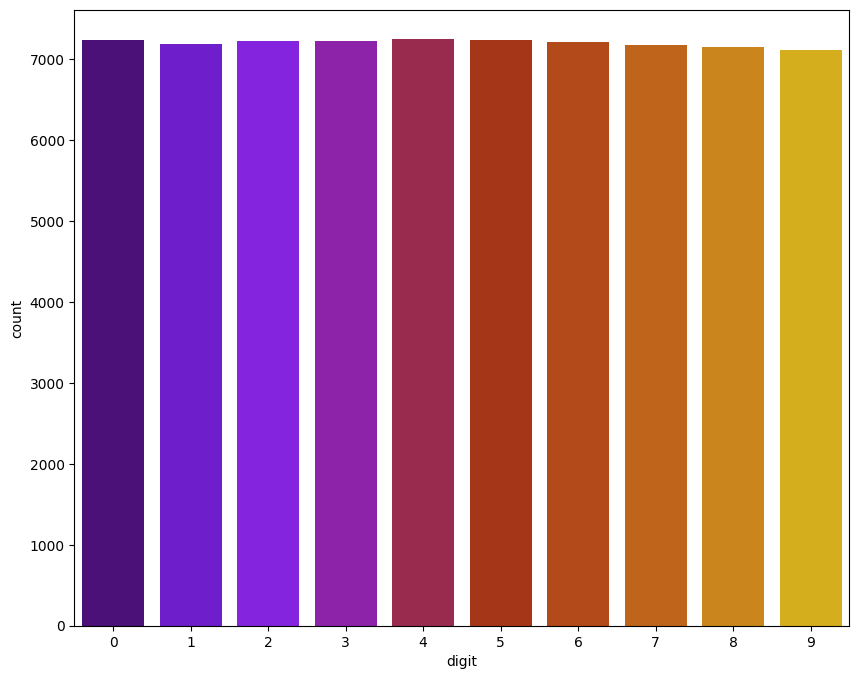

In [8]:
plt.figure(figsize=(10,8))
sns.countplot(data=train,x="digit",palette="gnuplot")
plt.show()

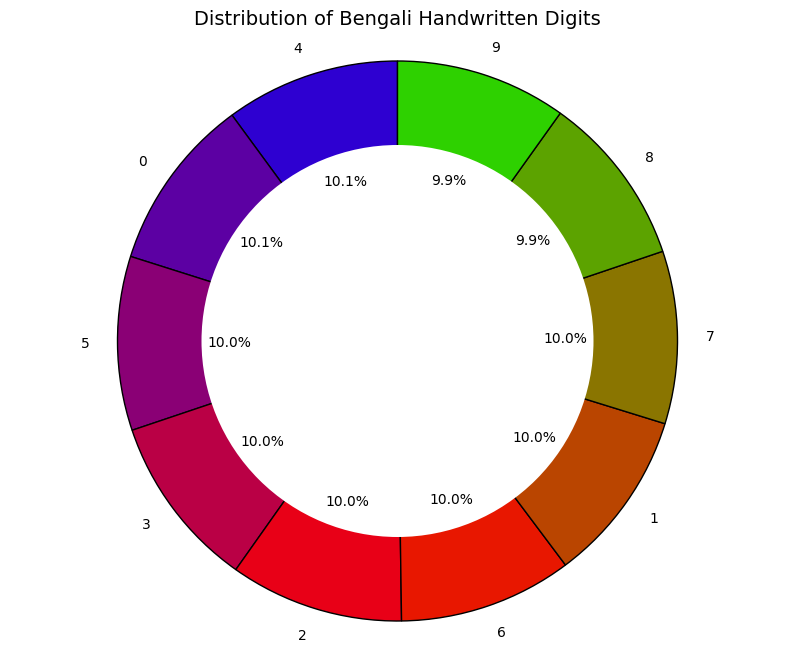

In [9]:
digit_counts = train['digit'].value_counts()

plt.figure(figsize=(10, 8))
colors = sns.color_palette("brg", len(digit_counts))
plt.pie(digit_counts, labels=digit_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)
plt.axis("equal")
plt.title("Distribution of Bengali Handwritten Digits", fontsize=14)
plt.show()

# Visualize images from train data

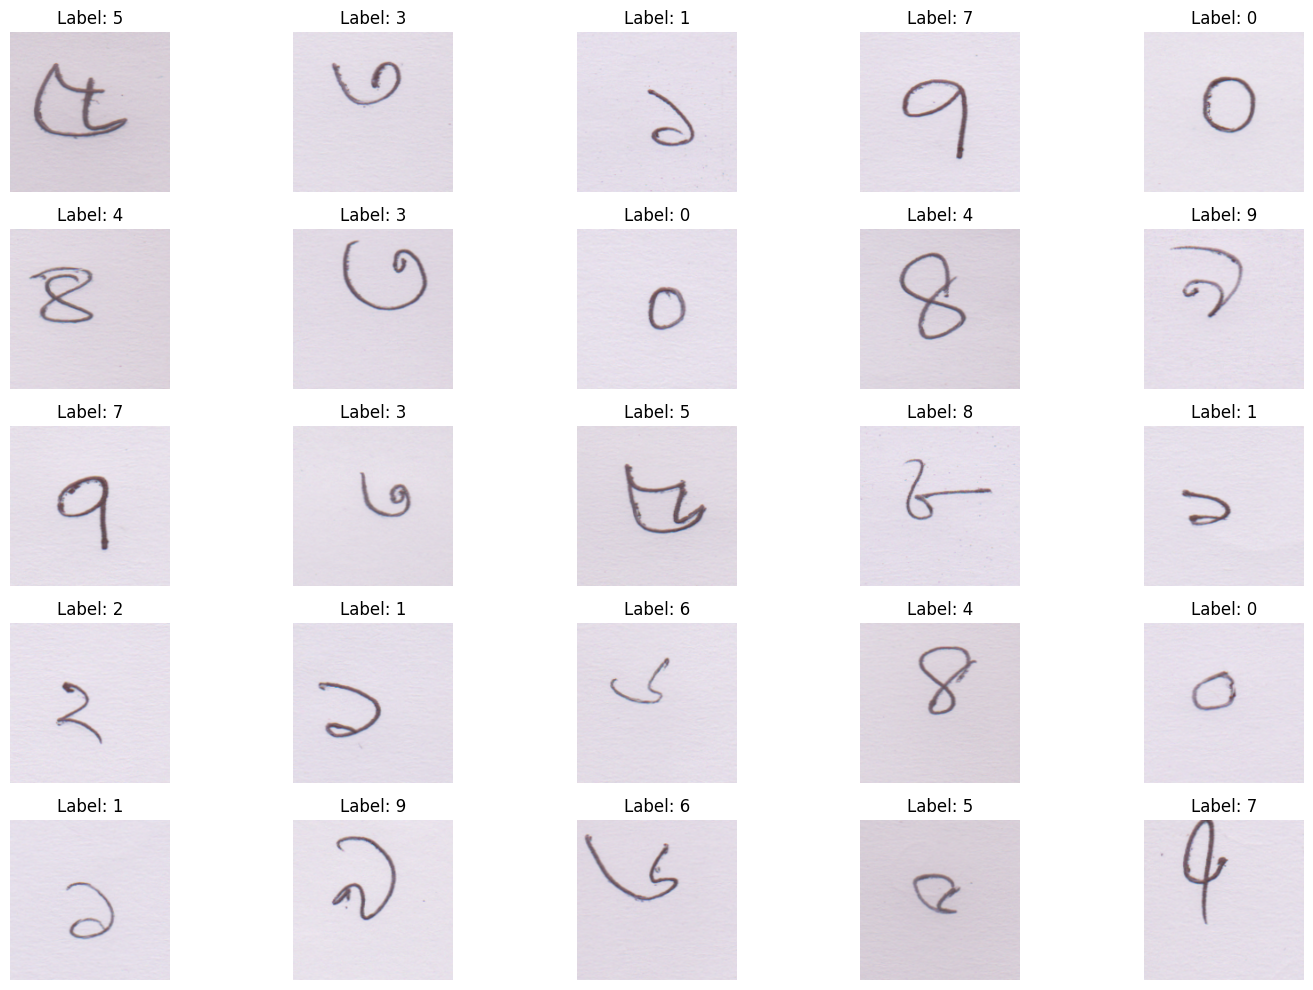

In [10]:
image_train_a="/kaggle/input/datasets/organizations/BengaliAI/numta/training-a/"
image_train_b="/kaggle/input/datasets/organizations/BengaliAI/numta/training-b/"
image_train_c="/kaggle/input/datasets/organizations/BengaliAI/numta/training-c/"
image_train_d="/kaggle/input/datasets/organizations/BengaliAI/numta/training-d/"
image_train_e="/kaggle/input/datasets/organizations/BengaliAI/numta/training-e/"
image_train_paths=[image_train_a,image_train_b,image_train_c,image_train_d,image_train_e]

fig, axes = plt.subplots(5, 5, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    if i < len(train):
        filename = train.iloc[i]["filename"]
        label = train.iloc[i]["digit"]

        img_path = None
        for folder in image_train_paths:
            path = os.path.join(folder, filename)
            if os.path.exists(path):
                img_path = path
                break

        if img_path:
            img = Image.open(img_path)
            ax.imshow(img, cmap="gray")
            ax.set_title(f"Label: {label}")
        else:
            ax.set_title("Not Found")

    ax.axis("off")

plt.tight_layout()
plt.show()


In [11]:
image_data = []

for i, row in tqdm(train.iterrows(), total=len(train), desc="Processing Images"):
    filename = row["filename"]
    label = row["digit"]

    img_path = None
    for folder in image_train_paths:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            img_path = path
            break

    if img_path:
        img = Image.open(img_path)
        image_data.append({"image": img, "label": label})

df_images = pd.DataFrame(image_data)

Processing Images:   0%|          | 0/72045 [00:00<?, ?it/s]

In [12]:
df_images.head()

,image,label
0,<PIL.PngImagePlugin.PngImageFile image mode=RG...,5
1,<PIL.PngImagePlugin.PngImageFile image mode=RG...,3
2,<PIL.PngImagePlugin.PngImageFile image mode=RG...,1
3,<PIL.PngImagePlugin.PngImageFile image mode=RG...,7
4,<PIL.PngImagePlugin.PngImageFile image mode=RG...,0


In [13]:
test_a = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-a/"
test_b = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-b/"
test_c = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-c/"
test_d = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-d/"
test_e = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-e/"
test_a_images = [os.path.join(test_a, f) for f in os.listdir(test_a) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
test_b_images = [os.path.join(test_b, f) for f in os.listdir(test_b) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
test_c_images = [os.path.join(test_c, f) for f in os.listdir(test_c) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
test_d_images = [os.path.join(test_d, f) for f in os.listdir(test_d) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
test_e_images = [os.path.join(test_e, f) for f in os.listdir(test_e) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
all_images = test_a_images + test_b_images + test_c_images + test_d_images + test_e_images
test= pd.DataFrame(all_images, columns=['imagefile'])
test.head()

,imagefile
0,/kaggle/input/datasets/organizations/BengaliAI...
1,/kaggle/input/datasets/organizations/BengaliAI...
2,/kaggle/input/datasets/organizations/BengaliAI...
3,/kaggle/input/datasets/organizations/BengaliAI...
4,/kaggle/input/datasets/organizations/BengaliAI...


In [14]:
test.shape

(12857, 1)

In [15]:
test.isnull().sum()

imagefile    0
dtype: int64

# visualize images from test data

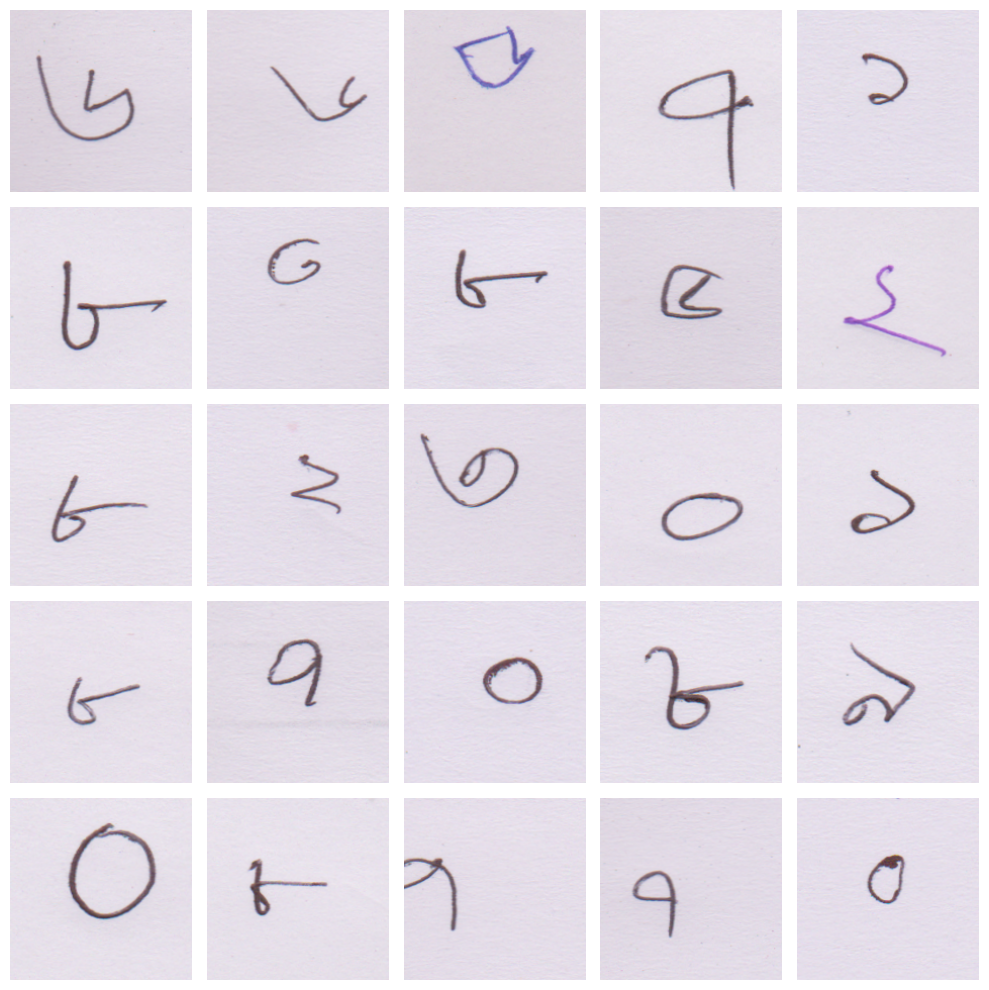

In [16]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < len(test):
        img_path = test.iloc[i]["imagefile"]
        img = Image.open(img_path)
        ax.imshow(img, cmap="gray")
    
    ax.axis("off")

plt.tight_layout()
plt.show()

# transform Images

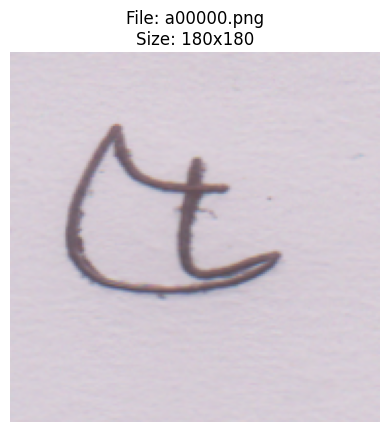

In [17]:
test_image = df_images["image"][0]
file_name = train.iloc[0]["filename"]  # Access the filename from the original DataFrame
image_size = test_image.size  # Get the image size (width, height)

plt.imshow(test_image)
plt.title(f"File: {file_name}\nSize: {image_size[0]}x{image_size[1]}")
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6451751..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79929787..2.2565577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.004795..2.64].


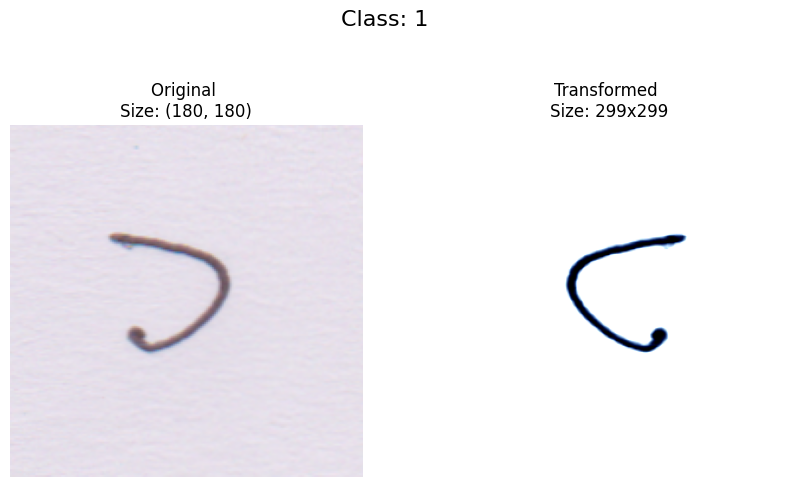

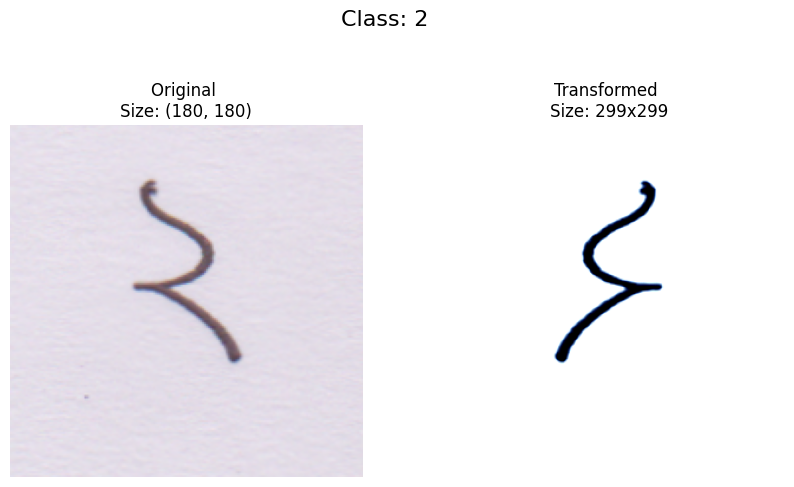

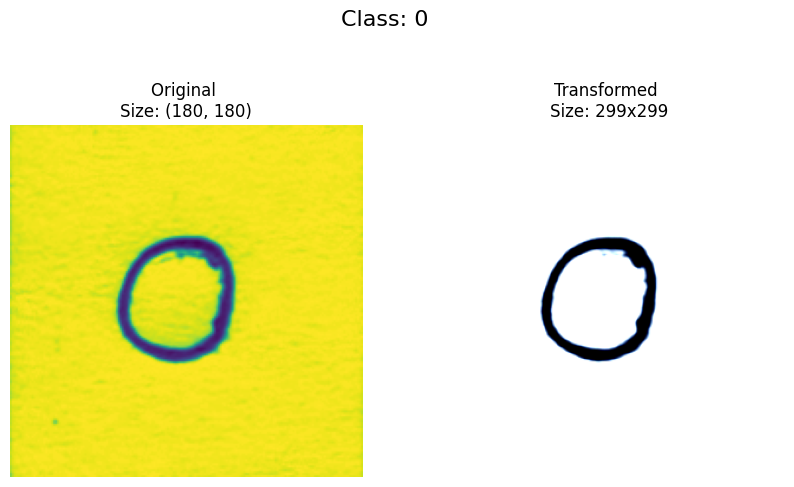

In [18]:
data_transform = transforms.Compose([
    transforms.Resize(size=(299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def plot_transformed_images_from_df(df_images, transform, n=3, seed=42):
    random.seed(seed)
    random_images = random.sample(range(len(df_images)), k=n)
    
    for idx in random_images:
        image = df_images.iloc[idx]["image"]
        label = df_images.iloc[idx]["label"]

        fig, ax = plt.subplots(1, 2, figsize=(10, 6))
        
        # Original image
        ax[0].imshow(image)
        ax[0].set_title(f"Original \nSize: {image.size}")
        ax[0].axis("off")

        # Transformed image
        transformed_image = transform(image).permute(1, 2, 0)
        ax[1].imshow(transformed_image)
        ax[1].set_title(f"Transformed \nSize: {transformed_image.shape[1]}x{transformed_image.shape[0]}")
        ax[1].axis("off")

        fig.suptitle(f"Class: {label}", fontsize=16)


plot_transformed_images_from_df(df_images, transform=data_transform, n=3)

# split the dataset

In [19]:
from sklearn.model_selection import train_test_split


train_df, valid_df = train_test_split(df_images, test_size=0.2, random_state=42)

# Display the number of samples in each set
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(valid_df)}")

Training set size: 57636
Validation set size: 14409
